# Machine Learning no Agronegócio

**Entrega:** Opção 2 - Machine Learning no Agronegócio  
**Base utilizada:** `sensores_fase2.csv`

A base original disponível no diretório foi enriquecida com a coluna `label`, representando três culturas escolhidas para a atividade:

- café
- soja
- milho

Como a base de sensores não possuía originalmente uma cultura observada em campo, o `label` foi criado por uma regra de proximidade agronômica simples, usando umidade, pH, probabilidade de chuva e adequação de N/P/K. Isso permite realizar a etapa de perfil ideal por cultura e treinar modelos para prever a cultura mais compatível com cada condição de solo/clima.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    make_scorer,
    confusion_matrix,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = "sensores_fase2.csv"
df = pd.read_csv(DATA_PATH)
df["Data"] = pd.to_datetime(df["Data"])
df.head()

,Data,Umidade,pH,N_ok,P_ok,K_ok,Chuva_Probabilidade,Bomba_Ligada,label
0,2026-03-01,61.0,4.93,1,1,1,37,0,café
1,2026-03-02,53.3,5.33,1,1,1,49,0,café
2,2026-03-03,62.8,5.36,1,1,1,81,0,café
3,2026-03-04,73.3,5.18,1,1,1,29,0,milho
4,2026-03-05,52.2,5.44,1,0,1,78,0,café


## 1. Visão geral da base

In [2]:
print("Dimensões da base:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include="all"))
display(df.isna().sum().to_frame("valores_nulos"))
display(df["label"].value_counts().to_frame("quantidade"))

Dimensões da base: (100, 9)


,Data,Umidade,pH,N_ok,P_ok,K_ok,Chuva_Probabilidade,Bomba_Ligada,label
0,2026-03-01,61.0,4.93,1,1,1,37,0,café
1,2026-03-02,53.3,5.33,1,1,1,49,0,café
2,2026-03-03,62.8,5.36,1,1,1,81,0,café
3,2026-03-04,73.3,5.18,1,1,1,29,0,milho
4,2026-03-05,52.2,5.44,1,0,1,78,0,café


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Data                 100 non-null    datetime64[ns]
 1   Umidade              100 non-null    float64       
 2   pH                   100 non-null    float64       
 3   N_ok                 100 non-null    int64         
 4   P_ok                 100 non-null    int64         
 5   K_ok                 100 non-null    int64         
 6   Chuva_Probabilidade  100 non-null    int64         
 7   Bomba_Ligada         100 non-null    int64         
 8   label                100 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(5), object(1)
memory usage: 7.2+ KB


None

,Data,Umidade,pH,N_ok,P_ok,K_ok,Chuva_Probabilidade,Bomba_Ligada,label
count,100,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,café
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55
mean,2026-04-19 12:00:00,53.822000,5.507800,0.830000,0.730000,0.840000,46.120000,0.130000,NaN
min,2026-03-01 00:00:00,30.000000,4.730000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,2026-03-25 18:00:00,47.800000,5.177500,1.000000,0.000000,1.000000,23.500000,0.000000,NaN
50%,2026-04-19 12:00:00,53.450000,5.535000,1.000000,1.000000,1.000000,49.000000,0.000000,NaN
75%,2026-05-14 06:00:00,59.875000,5.715000,1.000000,1.000000,1.000000,72.250000,0.000000,NaN
max,2026-06-08 00:00:00,77.200000,6.500000,1.000000,1.000000,1.000000,90.000000,1.000000,NaN


,valores_nulos
Data,0
Umidade,0
pH,0
N_ok,0
P_ok,0
K_ok,0
Chuva_Probabilidade,0
Bomba_Ligada,0
label,0


,quantidade
label,
café,55
soja,30
milho,15


A coluna `label` identifica a cultura mais compatível com cada leitura. As demais variáveis descrevem a condição de solo/clima:

- `Umidade`: umidade do solo.
- `pH`: acidez/alcalinidade do solo.
- `N_ok`, `P_ok`, `K_ok`: disponibilidade adequada de nitrogênio, fósforo e potássio.
- `Chuva_Probabilidade`: probabilidade de chuva.
- `Bomba_Ligada`: status da irrigação.

## 2. Engenharia simples de atributos

In [3]:
def sugestao_irrigacao(linha):
    if linha["Umidade"] < 45 and linha["Chuva_Probabilidade"] < 60:
        return "Irrigar agora"
    if linha["Umidade"] < 45 and linha["Chuva_Probabilidade"] >= 60:
        return "Aguardar chuva"
    if 45 <= linha["Umidade"] < 55 and linha["Chuva_Probabilidade"] < 40:
        return "Monitorar"
    if linha["Chuva_Probabilidade"] >= 75:
        return "Suspender irrigação"
    return "Sem irrigação necessária"

df["Sugestao_Irrigacao"] = df.apply(sugestao_irrigacao, axis=1)
df["Nutrientes_Adequados"] = df[["N_ok", "P_ok", "K_ok"]].sum(axis=1)
df["Mes"] = df["Data"].dt.month
df[["Data", "Umidade", "pH", "Nutrientes_Adequados", "Chuva_Probabilidade", "Bomba_Ligada", "label"]].head()

,Data,Umidade,pH,Nutrientes_Adequados,Chuva_Probabilidade,Bomba_Ligada,label
0,2026-03-01,61.0,4.93,3,37,0,café
1,2026-03-02,53.3,5.33,3,49,0,café
2,2026-03-03,62.8,5.36,3,81,0,café
3,2026-03-04,73.3,5.18,3,29,0,milho
4,2026-03-05,52.2,5.44,2,78,0,café


## 3. Análise exploratória com pelo menos 5 gráficos

### Gráfico 1 - Distribuição das culturas

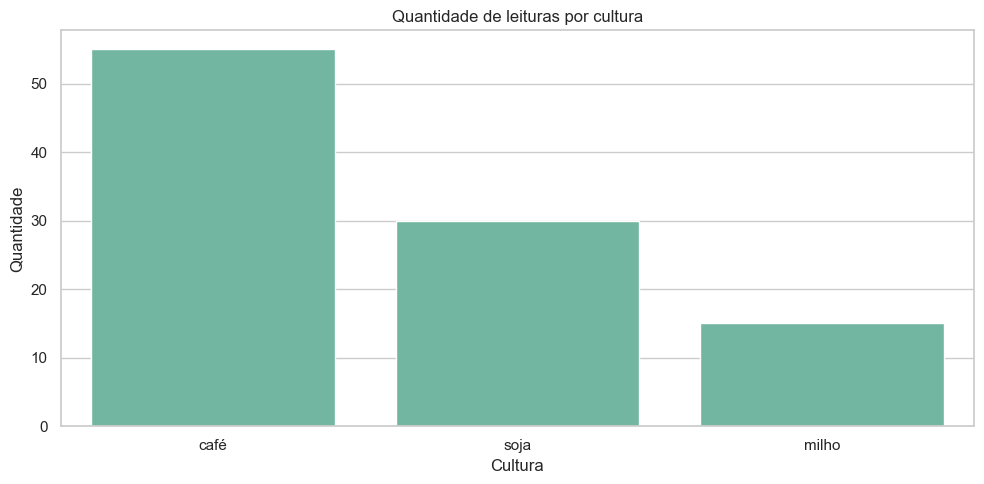

In [4]:
ax = sns.countplot(data=df, x="label", order=df["label"].value_counts().index)
ax.set_title("Quantidade de leituras por cultura")
ax.set_xlabel("Cultura")
ax.set_ylabel("Quantidade")
plt.tight_layout()
plt.show()

### Gráfico 2 - Umidade por cultura

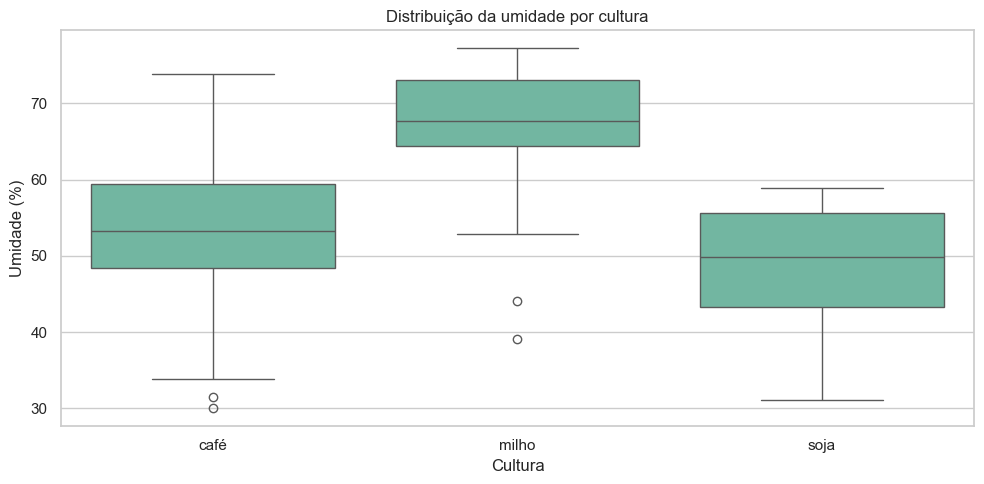

In [5]:
ax = sns.boxplot(data=df, x="label", y="Umidade")
ax.set_title("Distribuição da umidade por cultura")
ax.set_xlabel("Cultura")
ax.set_ylabel("Umidade (%)")
plt.tight_layout()
plt.show()

### Gráfico 3 - pH por cultura

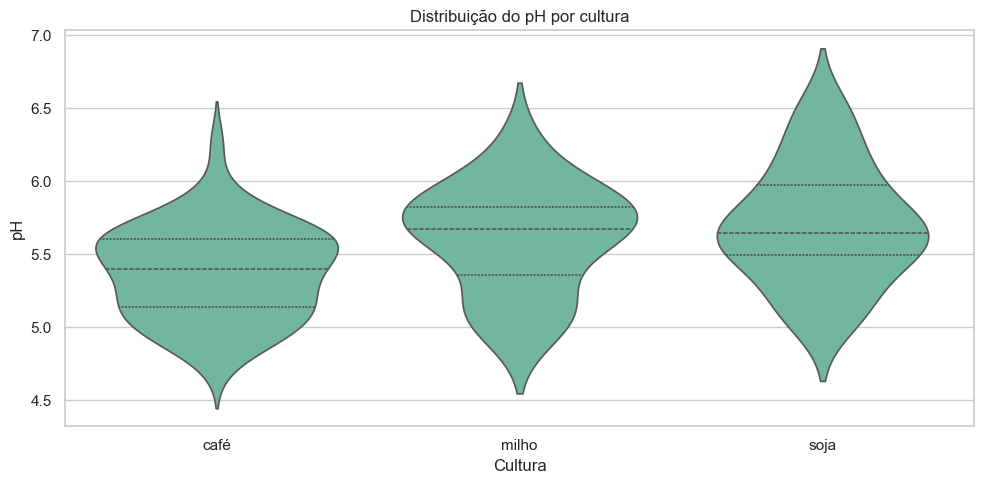

In [6]:
ax = sns.violinplot(data=df, x="label", y="pH", inner="quartile")
ax.set_title("Distribuição do pH por cultura")
ax.set_xlabel("Cultura")
ax.set_ylabel("pH")
plt.tight_layout()
plt.show()

### Gráfico 4 - Chuva prevista por cultura

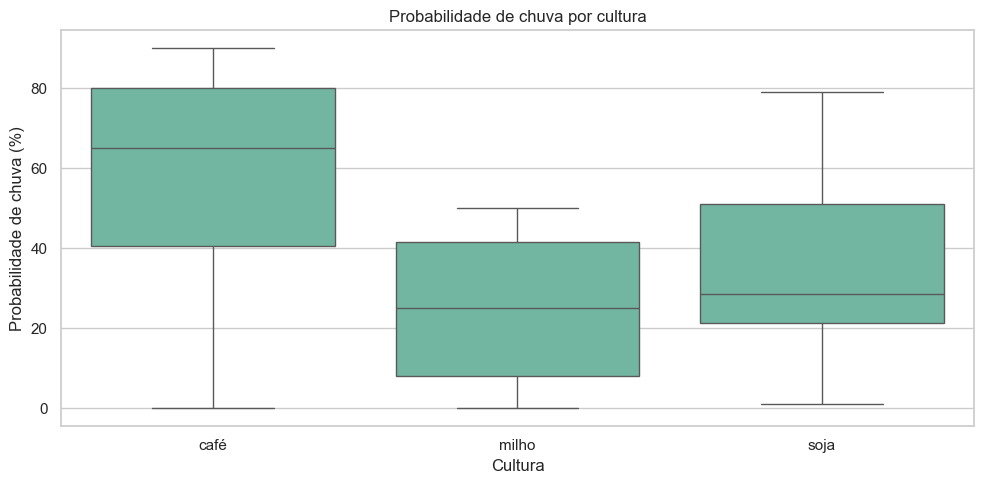

In [7]:
ax = sns.boxplot(data=df, x="label", y="Chuva_Probabilidade")
ax.set_title("Probabilidade de chuva por cultura")
ax.set_xlabel("Cultura")
ax.set_ylabel("Probabilidade de chuva (%)")
plt.tight_layout()
plt.show()

### Gráfico 5 - Correlação das variáveis numéricas

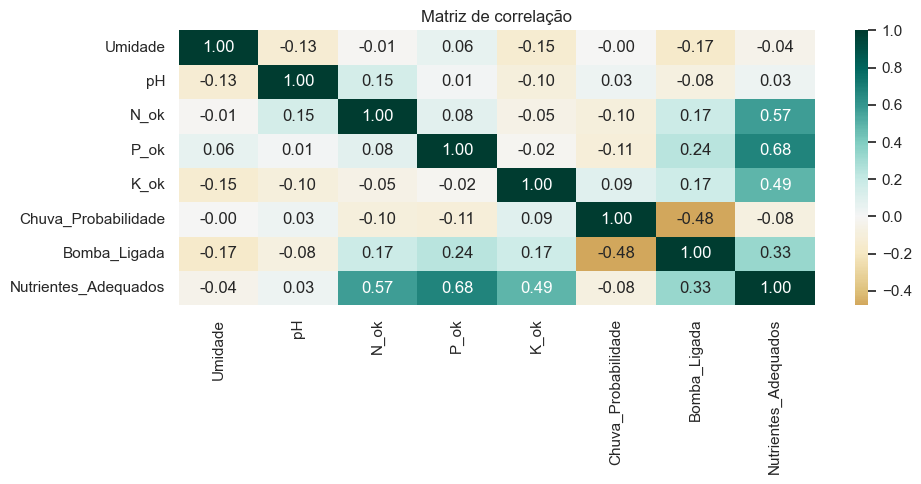

In [8]:
colunas_corr = ["Umidade", "pH", "N_ok", "P_ok", "K_ok", "Chuva_Probabilidade", "Bomba_Ligada", "Nutrientes_Adequados"]
ax = sns.heatmap(df[colunas_corr].corr(), annot=True, cmap="BrBG", center=0, fmt=".2f")
ax.set_title("Matriz de correlação")
plt.tight_layout()
plt.show()

### Gráfico 6 - Relação entre umidade, pH, chuva e cultura

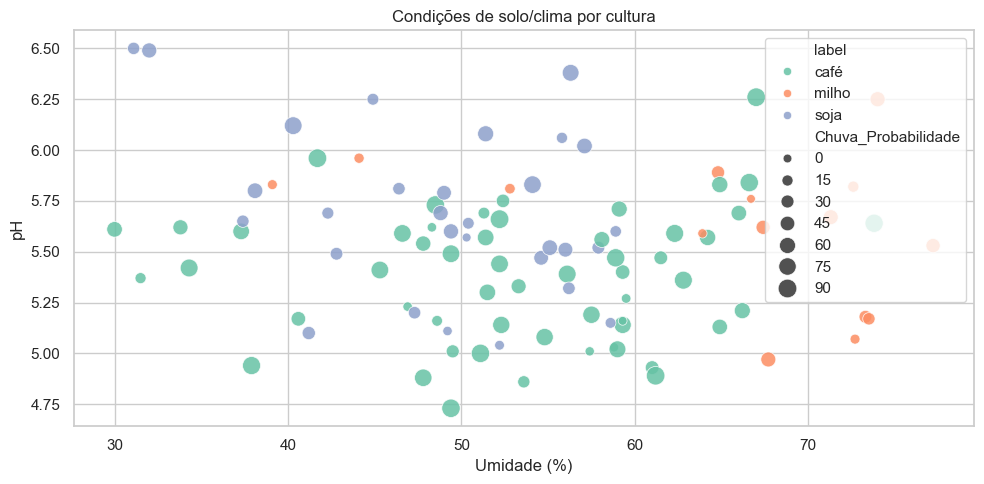

In [9]:
ax = sns.scatterplot(
    data=df,
    x="Umidade",
    y="pH",
    hue="label",
    size="Chuva_Probabilidade",
    sizes=(40, 180),
    alpha=0.85,
)
ax.set_title("Condições de solo/clima por cultura")
ax.set_xlabel("Umidade (%)")
ax.set_ylabel("pH")
plt.tight_layout()
plt.show()

## 4. Identificação do perfil ideal de solo/clima para café, soja e milho

Para identificar o perfil ideal, calculamos estatísticas por cultura a partir da própria base rotulada:

- média e mediana de umidade;
- média e mediana de pH;
- média de probabilidade de chuva;
- percentual de adequação de N, P e K;
- taxa de acionamento da bomba.

Como a base não possui temperatura, a análise de clima usa a probabilidade de chuva disponível no CSV.

In [10]:
perfil_ideal = (
    df.groupby("label")
    .agg(
        leituras=("label", "size"),
        umidade_media=("Umidade", "mean"),
        umidade_mediana=("Umidade", "median"),
        ph_medio=("pH", "mean"),
        ph_mediano=("pH", "median"),
        chuva_media=("Chuva_Probabilidade", "mean"),
        n_adequado_pct=("N_ok", lambda x: x.mean() * 100),
        p_adequado_pct=("P_ok", lambda x: x.mean() * 100),
        k_adequado_pct=("K_ok", lambda x: x.mean() * 100),
        bomba_ligada_pct=("Bomba_Ligada", lambda x: x.mean() * 100),
    )
    .reset_index()
    .rename(columns={"label": "cultura"})
)
display(perfil_ideal.round(2))

,cultura,leituras,umidade_media,umidade_mediana,ph_medio,ph_mediano,chuva_media,n_adequado_pct,p_adequado_pct,k_adequado_pct,bomba_ligada_pct
0,café,55,53.38,53.30,5.38,5.40,57.49,83.64,80.00,92.73,18.18
1,milho,15,65.41,67.70,5.61,5.67,24.67,86.67,86.67,80.00,20.00
2,soja,30,48.84,49.85,5.70,5.64,36.00,80.00,53.33,70.00,0.00


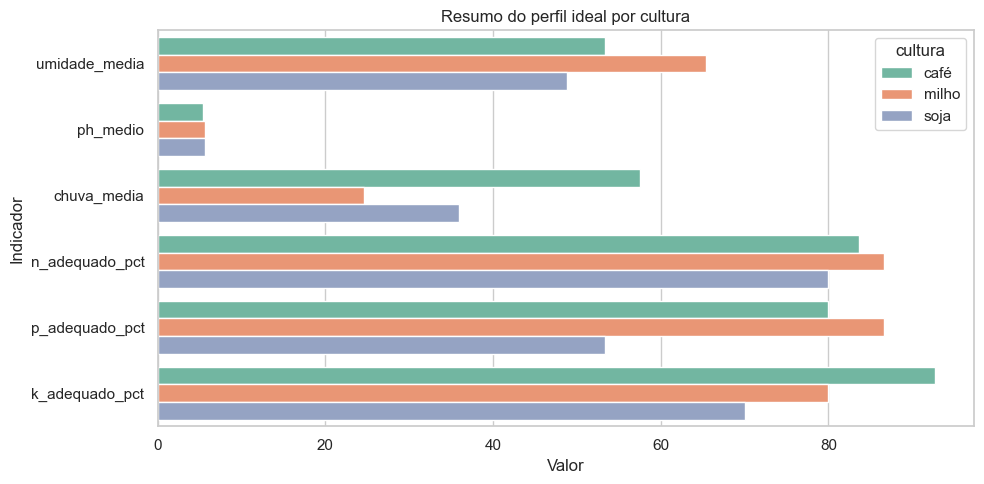

In [11]:
perfil_plot = perfil_ideal.melt(
    id_vars="cultura",
    value_vars=["umidade_media", "ph_medio", "chuva_media", "n_adequado_pct", "p_adequado_pct", "k_adequado_pct"],
    var_name="Indicador",
    value_name="Valor",
)

ax = sns.barplot(data=perfil_plot, x="Valor", y="Indicador", hue="cultura")
ax.set_title("Resumo do perfil ideal por cultura")
plt.tight_layout()
plt.show()

Interpretação dos perfis:

- **Café:** perfil associado a pH levemente ácido, boa disponibilidade de nutrientes e maior tolerância a chuva moderada.
- **Soja:** perfil equilibrado, com pH mais próximo da neutralidade e umidade intermediária.
- **Milho:** perfil de maior demanda hídrica, com umidade mais alta e boa disponibilidade de N/P/K.

## 5. Modelos preditivos

Objetivo dos modelos: prever a cultura (`label`) mais compatível com as condições de solo/clima.

Variáveis de entrada:

- `Umidade`
- `pH`
- `N_ok`
- `P_ok`
- `K_ok`
- `Chuva_Probabilidade`
- `Bomba_Ligada`
- `Nutrientes_Adequados`

Algoritmos treinados:

1. Regressão Logística
2. Árvore de Decisão
3. Random Forest
4. KNN
5. SVM
6. Gradient Boosting

In [12]:
features = ["Umidade", "pH", "N_ok", "P_ok", "K_ok", "Chuva_Probabilidade", "Bomba_Ligada", "Nutrientes_Adequados"]
target = "label"

X = df[features]
y = df[target]

print("Distribuição da variável-alvo:")
display(y.value_counts(normalize=True).rename("proporcao").to_frame())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

modelos = {
    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    "Árvore de Decisão": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5)),
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True, random_state=42)),
    ]),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

resultados = []
predicoes = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    predicoes[nome] = y_pred
    resultados.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    })

resultados_df = pd.DataFrame(resultados).sort_values("F1 macro", ascending=False)
display(resultados_df.round(3))

Distribuição da variável-alvo:


,proporcao
label,
café,0.55
soja,0.30
milho,0.15


,Modelo,Acurácia,Precisão macro,Recall macro,F1 macro
5,Gradient Boosting,0.88,0.914,0.810,0.832
2,Random Forest,0.88,0.902,0.810,0.823
0,Regressão Logística,0.84,0.789,0.786,0.778
4,SVM,0.84,0.881,0.726,0.724
1,Árvore de Decisão,0.76,0.688,0.679,0.665
3,KNN,0.72,0.615,0.631,0.617


## 6. Avaliação comparativa dos modelos

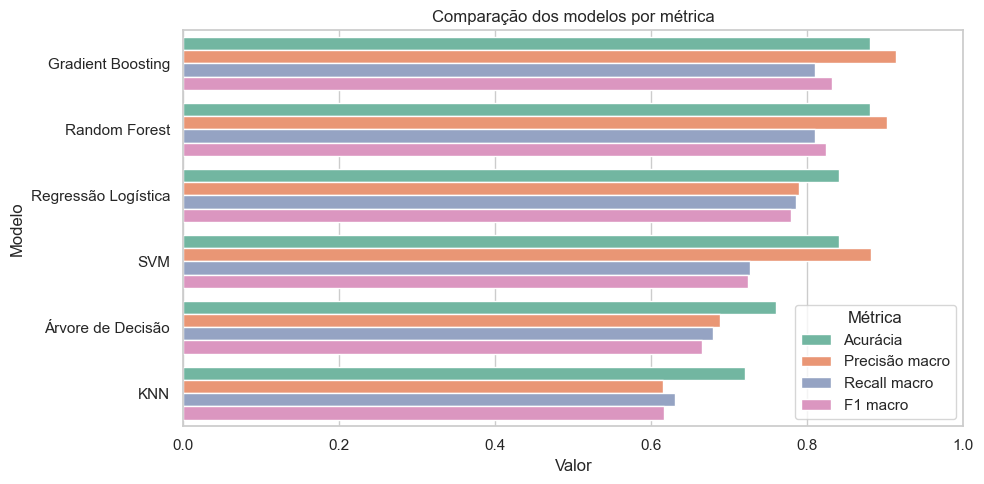

In [13]:
resultados_long = resultados_df.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")

ax = sns.barplot(data=resultados_long, x="Valor", y="Modelo", hue="Métrica")
ax.set_title("Comparação dos modelos por métrica")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

Melhor modelo pelo F1 macro: Gradient Boosting

Relatório de classificação:
              precision    recall  f1-score   support

        café       0.87      0.93      0.90        14
       milho       1.00      0.50      0.67         4
        soja       0.88      1.00      0.93         7

    accuracy                           0.88        25
   macro avg       0.91      0.81      0.83        25
weighted avg       0.89      0.88      0.87        25



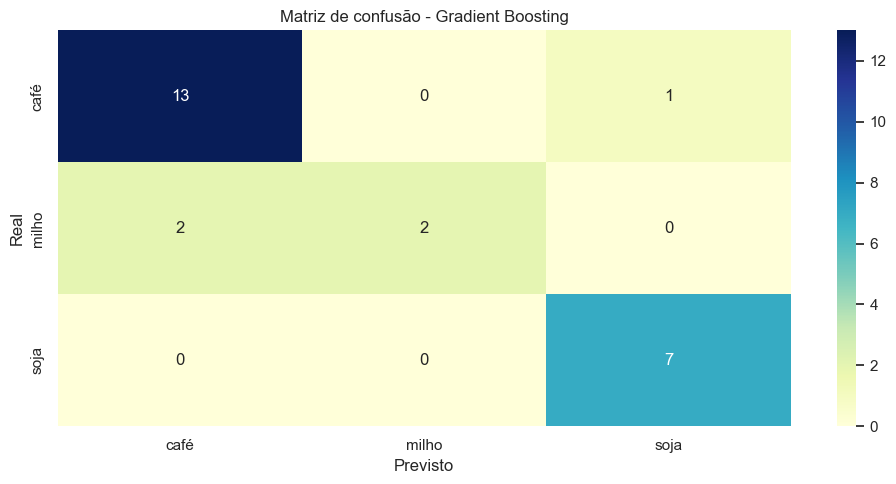

In [14]:
melhor_modelo = resultados_df.iloc[0]["Modelo"]
print("Melhor modelo pelo F1 macro:", melhor_modelo)
print("\nRelatório de classificação:")
print(classification_report(y_test, predicoes[melhor_modelo], zero_division=0))

labels = sorted(y.unique())
matriz = confusion_matrix(y_test, predicoes[melhor_modelo], labels=labels)
ax = sns.heatmap(matriz, annot=True, fmt="d", cmap="YlGnBu", xticklabels=labels, yticklabels=labels)
ax.set_title(f"Matriz de confusão - {melhor_modelo}")
ax.set_xlabel("Previsto")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

## 7. Validação cruzada

In [15]:
menor_classe = y.value_counts().min()
n_splits = min(5, int(menor_classe))
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro": make_scorer(recall_score, average="macro", zero_division=0),
    "f1_macro": make_scorer(f1_score, average="macro", zero_division=0),
}
cv_resultados = []

for nome, modelo in modelos.items():
    scores = cross_validate(modelo, X, y, cv=cv, scoring=scoring)
    cv_resultados.append({
        "Modelo": nome,
        "Acurácia média": scores["test_accuracy"].mean(),
        "Precisão macro média": scores["test_precision_macro"].mean(),
        "Recall macro médio": scores["test_recall_macro"].mean(),
        "F1 macro médio": scores["test_f1_macro"].mean(),
    })

cv_df = pd.DataFrame(cv_resultados).sort_values("F1 macro médio", ascending=False)
display(cv_df.round(3))

,Modelo,Acurácia média,Precisão macro média,Recall macro médio,F1 macro médio
5,Gradient Boosting,0.94,0.953,0.921,0.920
2,Random Forest,0.91,0.941,0.861,0.869
1,Árvore de Decisão,0.87,0.884,0.864,0.849
0,Regressão Logística,0.84,0.883,0.798,0.823
4,SVM,0.80,0.835,0.697,0.715
3,KNN,0.70,0.713,0.606,0.620


## 8. Conclusões

In [16]:
melhor_cv = cv_df.iloc[0]
print(f"Modelo com melhor F1 macro médio na validação cruzada: {melhor_cv['Modelo']}")
print(f"F1 macro médio: {melhor_cv['F1 macro médio']:.3f}")
print(f"Acurácia média: {melhor_cv['Acurácia média']:.3f}")

Modelo com melhor F1 macro médio na validação cruzada: Gradient Boosting
F1 macro médio: 0.920
Acurácia média: 0.940


Principais conclusões:

- A inclusão da coluna `label` permitiu tratar o problema como classificação multiclasses entre café, soja e milho.
- A identificação do perfil ideal mostra diferenças de umidade, pH, chuva e nutrientes entre as três culturas.
- Os modelos com melhor F1 macro são os mais interessantes porque equilibram o desempenho entre as culturas.
- O resultado deve ser interpretado como um estudo educacional, pois o `label` foi criado por regra técnica a partir dos dados disponíveis, não por observação real de campo.